# Week 1 — Agribusiness Data Collection & Cleaning

**Dataset:** `agriculture_dataset.csv`  
**Objective:** Inspect, clean, validate, summarize, and prepare an agribusiness dataset for downstream analysis/ML.

This notebook covers:
- Dataset loading and initial inspection
- Data types and schema validation
- Missing-value analysis and treatment
- Duplicate detection/removal
- Categorical-value validation
- IQR-based outlier detection
- Statistical summary
- Feature engineering for agribusiness analysis
- Standardization for ML-ready numerical features
- Visual validation
- Export of cleaned datasets

> **Important:** The supplied dataset contains 50 farm records and 10 original fields. The cleaned master dataset preserves the original measurement units so it remains interpretable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# If running from the same folder as this notebook:
DATA_PATH = "agriculture_dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (50, 10)


,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


## 1. Initial Dataset Inspection

In [2]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

Rows: 50
Columns: 10

Column names:
['Farm_ID', 'Crop_Type', 'Farm_Area(acres)', 'Irrigation_Type', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)', 'Soil_Type', 'Season', 'Water_Usage(cubic meters)']

Data types:


,dtype
Farm_ID,object
Crop_Type,object
Farm_Area(acres),float64
Irrigation_Type,object
Fertilizer_Used(tons),float64
Pesticide_Used(kg),float64
Yield(tons),float64
Soil_Type,object
Season,object
Water_Usage(cubic meters),float64



Missing values:


,missing_count
Farm_ID,0
Crop_Type,0
Farm_Area(acres),0
Irrigation_Type,0
Fertilizer_Used(tons),0
Pesticide_Used(kg),0
Yield(tons),0
Soil_Type,0
Season,0
Water_Usage(cubic meters),0



Duplicate rows: 0


## 2. Data Cleaning and Standardization

In [3]:
clean = df.copy()

# Standardize column names for easier Python/ML use.
clean.columns = [
    c.strip().lower().replace("(", "_").replace(")", "")
     .replace(" ", "_").replace("/", "_")
    for c in clean.columns
]

# Clean text fields and recognize common missing-value tokens.
cat_cols = clean.select_dtypes(include="object").columns
for c in cat_cols:
    clean[c] = clean[c].astype(str).str.strip()
    clean[c] = clean[c].replace({"": np.nan, "NA": np.nan, "N/A": np.nan,
                                 "null": np.nan, "None": np.nan})

# Convert non-categorical fields to numeric.
for c in clean.columns:
    if c not in cat_cols:
        clean[c] = pd.to_numeric(clean[c], errors="coerce")

# Remove exact duplicate records.
before = len(clean)
clean = clean.drop_duplicates().reset_index(drop=True)
print("Duplicate rows removed:", before - len(clean))

print("\nMissing values after cleaning:")
display(clean.isna().sum().to_frame("missing_count"))

Duplicate rows removed: 0

Missing values after cleaning:


,missing_count
farm_id,0
crop_type,0
farm_area_acres,0
irrigation_type,0
fertilizer_used_tons,0
pesticide_used_kg,0
yield_tons,0
soil_type,0
season,0
water_usage_cubic_meters,0


### Missing-value strategy

No missing values are present in the supplied dataset, so no imputation was required. If missing values had existed, numerical variables would be candidates for median imputation (more robust to skew/outliers), while categorical variables would generally use the mode or an explicit `Unknown` category depending on the modeling objective.

## 3. Categorical Data Validation

In [4]:
for c in clean.select_dtypes(include="object").columns:
    print(f"\n{c}:")
    display(clean[c].value_counts(dropna=False).to_frame("count"))


farm_id:


,count
farm_id,
F001,1
F002,1
F003,1
F004,1
F005,1
F006,1
F007,1
F008,1
F009,1



crop_type:


,count
crop_type,
Cotton,7
Barley,7
Tomato,6
Rice,5
Soybean,5
Sugarcane,5
Carrot,4
Wheat,4
Potato,4



irrigation_type:


,count
irrigation_type,
Drip,15
Flood,13
Sprinkler,9
Rain-fed,7
Manual,6



soil_type:


,count
soil_type,
Clay,14
Loamy,11
Sandy,11
Silty,10
Peaty,4



season:


,count
season,
Zaid,23
Kharif,16
Rabi,11


## 4. IQR-Based Outlier Detection

In [5]:
numeric_cols = clean.select_dtypes(include=np.number).columns.tolist()

rows = []
for c in numeric_cols:
    q1 = clean[c].quantile(0.25)
    q3 = clean[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (clean[c] < lower) | (clean[c] > upper)
    rows.append([c, q1, q3, iqr, lower, upper, int(mask.sum())])

outlier_df = pd.DataFrame(
    rows,
    columns=["Column","Q1","Q3","IQR","Lower_Bound","Upper_Bound","Outliers"]
)
display(outlier_df)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outliers
0,farm_area_acres,135.7100,368.1075,232.3975,-212.88625,716.70375,0
1,fertilizer_used_tons,2.4375,6.8850,4.4475,-4.23375,13.55625,0
2,pesticide_used_kg,0.9725,3.4175,2.4450,-2.69500,7.08500,0
3,yield_tons,16.1900,37.8600,21.6700,-16.31500,70.36500,0
4,water_usage_cubic_meters,37818.1525,82240.0325,44421.8800,-28814.66750,148872.85250,0


### Outlier decision

The IQR rule identifies **zero outliers across all numerical variables**. Therefore, no observations were deleted or winsorized. This avoids removing legitimate agricultural variation simply because values are relatively high or low.

## 5. Statistical Summary

In [6]:
display(clean.describe().T)

print("\nCategorical summary:")
display(clean.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
farm_area_acres,50.0,254.9638,139.417782,12.50,135.7100,281.980,368.1075,483.88
fertilizer_used_tons,50.0,4.9054,2.732689,0.50,2.4375,5.045,6.8850,9.96
pesticide_used_kg,50.0,2.3980,1.438613,0.14,0.9725,2.330,3.4175,4.99
yield_tons,50.0,27.0592,13.345789,3.86,16.1900,28.970,37.8600,48.02
water_usage_cubic_meters,50.0,56724.2956,27264.992053,5869.75,37818.1525,54097.075,82240.0325,94754.73



Categorical summary:


,count,unique,top,freq
farm_id,50,50,F001,1
crop_type,50,10,Cotton,7
irrigation_type,50,5,Drip,15
soil_type,50,5,Clay,14
season,50,3,Zaid,23


## 6. Agribusiness Feature Engineering

In [7]:
analysis = clean.copy()

# Useful operational indicators.
analysis["yield_per_acre"] = analysis["yield_tons"] / analysis["farm_area_acres"]
analysis["fertilizer_per_acre"] = analysis["fertilizer_used_tons"] / analysis["farm_area_acres"]
analysis["pesticide_per_acre"] = analysis["pesticide_used_kg"] / analysis["farm_area_acres"]
analysis["water_per_acre"] = analysis["water_usage_cubic_meters"] / analysis["farm_area_acres"]

display(analysis[[
    "farm_id", "crop_type", "farm_area_acres", "yield_tons",
    "yield_per_acre", "fertilizer_per_acre",
    "pesticide_per_acre", "water_per_acre"
]].head())

,farm_id,crop_type,farm_area_acres,yield_tons,yield_per_acre,fertilizer_per_acre,pesticide_per_acre,water_per_acre
0,F001,Cotton,329.40,14.44,0.043837,0.024712,0.006709,232.690346
1,F002,Carrot,18.67,42.91,2.298340,0.255490,0.233530,3681.068024
2,F003,Sugarcane,306.03,33.44,0.109270,0.009509,0.001830,246.833840
3,F004,Tomato,380.21,34.08,0.089635,0.008732,0.011441,119.410931
4,F005,Tomato,135.56,43.28,0.319268,0.061449,0.033048,691.344718


## 7. Standardization for Machine Learning

In [8]:
# Preserve clean data in original units; standardize only a separate analytical copy.
scaled = clean.copy()

for c in numeric_cols:
    mean = scaled[c].mean()
    std = scaled[c].std(ddof=0)
    if std != 0:
        scaled[c] = (scaled[c] - mean) / std

display(scaled.head())

print("Mean of standardized numerical features (approximately 0):")
display(scaled[numeric_cols].mean().round(6).to_frame("mean"))

,farm_id,crop_type,farm_area_acres,irrigation_type,fertilizer_used_tons,pesticide_used_kg,yield_tons,soil_type,season,water_usage_cubic_meters
0,F001,Cotton,0.539328,Sprinkler,1.195687,-0.132008,-0.955156,Loamy,Kharif,0.738169
1,F002,Carrot,-1.712068,Manual,-0.050051,1.377660,1.199759,Peaty,Kharif,0.444639
2,F003,Sugarcane,0.370001,Flood,-0.737610,-1.290590,0.482967,Silty,Kharif,0.697058
3,F004,Tomato,0.907472,Rain-fed,-0.586051,1.370638,0.531409,Silty,Zaid,-0.419513
4,F005,Tomato,-0.865141,Sprinkler,1.265921,1.461920,1.227764,Clay,Zaid,1.370621


Mean of standardized numerical features (approximately 0):


,mean
farm_area_acres,-0.0
fertilizer_used_tons,-0.0
pesticide_used_kg,-0.0
yield_tons,-0.0
water_usage_cubic_meters,0.0


## 8. Visual Validation

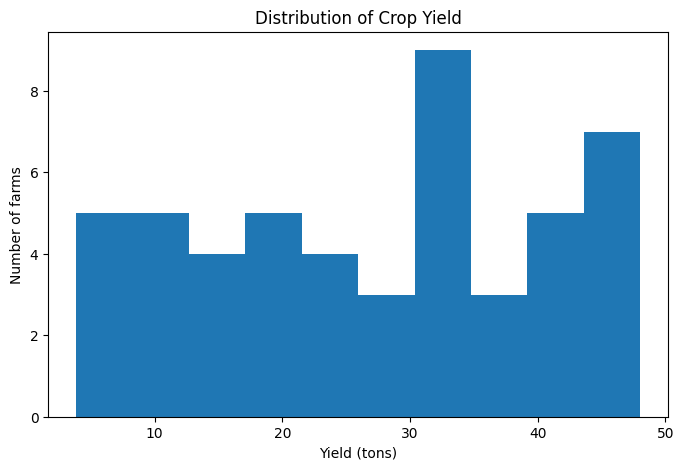

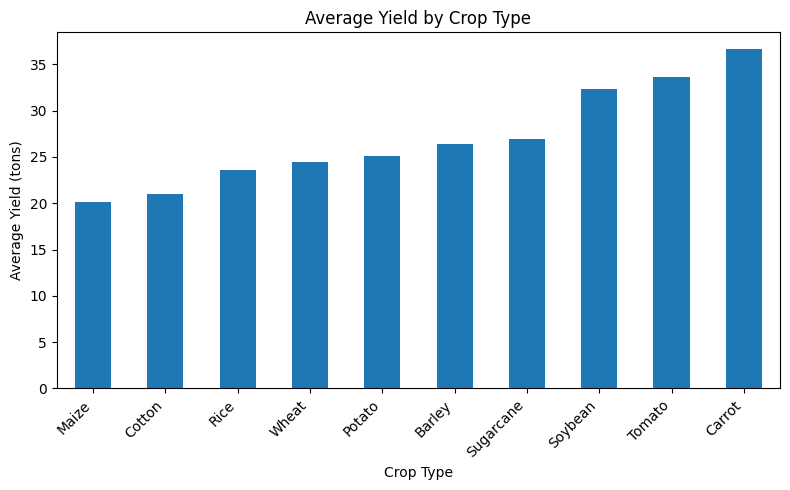

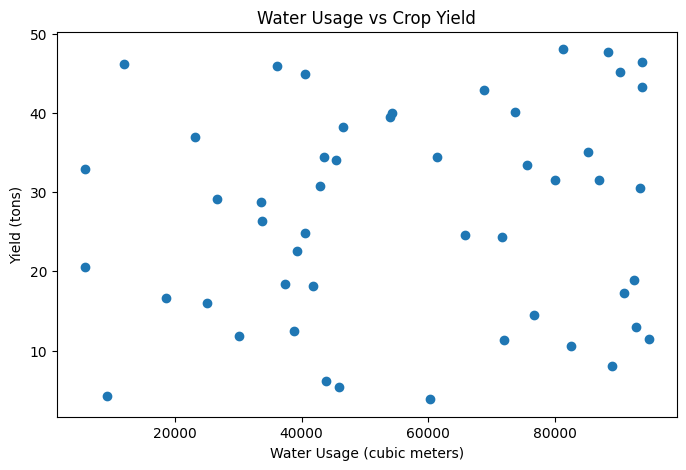

In [9]:
plt.figure(figsize=(8,5))
plt.hist(clean["yield_tons"], bins=10)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (tons)")
plt.ylabel("Number of farms")
plt.show()

plt.figure(figsize=(8,5))
clean.groupby("crop_type")["yield_tons"].mean().sort_values().plot(kind="bar")
plt.title("Average Yield by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Average Yield (tons)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(clean["water_usage_cubic_meters"], clean["yield_tons"])
plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Usage (cubic meters)")
plt.ylabel("Yield (tons)")
plt.show()

## 9. Export Final Datasets

In [10]:
clean.to_csv("cleaned_agriculture_dataset.csv", index=False)
scaled.to_csv("standardized_agriculture_dataset.csv", index=False)

print("Saved:")
print("- cleaned_agriculture_dataset.csv")
print("- standardized_agriculture_dataset.csv")
print("\nFinal cleaned shape:", clean.shape)

Saved:
- cleaned_agriculture_dataset.csv
- standardized_agriculture_dataset.csv

Final cleaned shape: (50, 10)


## 10. Final Findings

- The dataset contains **50 farm records and 10 original variables**.
- No missing values were found.
- No exact duplicate records were found.
- All numerical fields were already stored as numeric values.
- Categorical fields were inspected for consistency.
- IQR analysis detected **no numerical outliers**, so no records were removed.
- The cleaned master dataset remains in original measurement units for interpretability.
- A separate standardized copy was created for potential ML workflows.
- Additional agribusiness indicators such as yield per acre and resource use per acre were demonstrated.

**Limitation:** This is a relatively small dataset, so conclusions about relationships between farming practices and yield should be treated as exploratory rather than broadly representative.